# Step-34.1: Turnover Engine Audit and Threshold Rebalance Redesign

## Financial Market Trend Forecasting Using Ensemble Learning and Deep Sequence Models

This notebook is an execution-engine audit and redesign study.

**Scope constraints (strict):**
- Keep Step-28 alpha signal unchanged.
- No new features, no new models, no ensemble redesign.
- Focus purely on turnover destruction diagnostics and threshold-based execution control.


## Leakage-Safe Execution Protocol

This notebook enforces institutional anti-leakage rules:

1. Signals are observed at date `t`.
2. Weights decided at `t` are executed for returns realized at `t+1`.
3. Portfolio PnL at date `t` uses **previous-day weights** only.
4. Transaction costs apply only on weight transitions.
5. Volatility estimates for sizing use shifted history only.

This corresponds to purged temporal logic and avoids same-row signal/return contamination.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

pd.set_option("display.max_columns", 400)
pd.set_option("display.width", 260)

CFG = {
    "start_date": "2023-01-01",
    "end_date": "2026-01-01",
    "tx_cost_bps": 20.0,
    "slippage_bps": 5.0,
    "annualization_days": 252,
    "vol_lookback": 40,
    "target_gross_exposure": 1.0,
    "max_single_weight": 0.10,
    "max_net_exposure": 0.10,
    "rebal_frequency": 3,
    "long_threshold": 0.75,
    "short_threshold": 0.25,
    "max_long_positions": 10,
    "max_short_positions": 10,
    "retain_long_rank": 0.60,
    "retain_short_rank": 0.40,
    "rank_drift_threshold": 0.08,
    "weight_change_threshold": 0.015,
    "alpha_gain_multiplier": 1.0,
    "allowed_regimes": ["HIGH", "MEDIUM", "LOW"],
    "smoothing_halflife_options": [None, 1, 2, 3],
    "ic_damage_tolerance": -0.0025,
}


def resolve_project_root() -> Path:
    cwd = Path.cwd()
    for p in [cwd, cwd.parent, cwd.parent.parent]:
        if (p / "ml_pipeline").exists():
            return p
    raise FileNotFoundError("Project root not found.")


ROOT = resolve_project_root()
BASE = ROOT / "ml_pipeline"
FINAL_DIR = BASE / "Market_Data" / "final"
PROC_DIR = BASE / "Market_Data" / "processed"

STEP28_PATH = FINAL_DIR / "cross_sectional_alpha_results.parquet"
STEP33_PATH = FINAL_DIR / "step33_cost_aware_portfolio.parquet"
STEP34_PATH = FINAL_DIR / "step34_low_turnover_portfolio.parquet"
FINAL_MODEL_PATH = PROC_DIR / "final_model_dataset.parquet"

OUT_AUDIT = FINAL_DIR / "step34_1_turnover_audit.csv"
OUT_DECOMP = FINAL_DIR / "step34_1_turnover_decomposition.csv"
OUT_THRESH = FINAL_DIR / "step34_1_threshold_analysis.csv"
OUT_REG = FINAL_DIR / "step34_1_regime_analysis.csv"
OUT_SUM = FINAL_DIR / "step34_1_summary.csv"
OUT_PORT = FINAL_DIR / "step34_1_threshold_rebalance_portfolio.parquet"

assert STEP28_PATH.exists(), f"Missing {STEP28_PATH}"


In [2]:
def standardize(df: pd.DataFrame) -> pd.DataFrame:
    mp = {}
    for c in df.columns:
        cl = c.lower()
        if cl == "date":
            mp[c] = "date"
        elif cl == "ticker":
            mp[c] = "ticker"
        elif cl in {"pred_score", "pred_lightgbmregressor", "pred_final"} and "pred_score" not in mp.values():
            mp[c] = "pred_score"
        elif cl in {"actual_return", "target_future_return_t3"} and "actual_return" not in mp.values():
            mp[c] = "actual_return"
        elif cl == "regime":
            mp[c] = "regime"
    x = df.rename(columns=mp).copy()
    req = ["date", "ticker", "pred_score", "actual_return"]
    miss = [c for c in req if c not in x.columns]
    if miss:
        raise ValueError(f"Missing required columns: {miss}")
    if "regime" not in x.columns:
        x["regime"] = np.nan
    return x


raw = pd.read_parquet(STEP28_PATH)
df = standardize(raw)
df["date"] = pd.to_datetime(df["date"])
df = df[(df["date"] >= pd.Timestamp(CFG["start_date"])) & (df["date"] <= pd.Timestamp(CFG["end_date"]))].copy()
df["ticker"] = df["ticker"].astype(str)
df = df.drop_duplicates(["date", "ticker"]).sort_values(["ticker", "date"]).reset_index(drop=True)

if df["regime"].isna().all():
    fm = pd.read_parquet(FINAL_MODEL_PATH, columns=["Date", "Ticker", "Volatility_20"]).rename(columns={"Date": "date", "Ticker": "ticker"})
    fm["date"] = pd.to_datetime(fm["date"])
    train = fm[(fm["date"] >= pd.Timestamp("2023-01-01")) & (fm["date"] <= pd.Timestamp("2024-12-31"))]["Volatility_20"].dropna()
    q1, q2 = train.quantile([1 / 3, 2 / 3]).values if len(train) else (fm["Volatility_20"].quantile(1 / 3), fm["Volatility_20"].quantile(2 / 3))
    fm["regime"] = np.where(fm["Volatility_20"] <= q1, "LOW", np.where(fm["Volatility_20"] <= q2, "MEDIUM", "HIGH"))
    df = df.drop(columns=["regime"]).merge(fm[["date", "ticker", "regime"]], on=["date", "ticker"], how="left")

df["regime"] = df["regime"].astype(str).str.upper().fillna("MEDIUM")
df["rank_raw"] = df.groupby("date")["pred_score"].rank(pct=True, method="average")

# shifted vol for inverse-vol weighting
df["vol_est"] = (
    df.sort_values(["ticker", "date"])
    .groupby("ticker")["actual_return"]
    .transform(lambda s: s.rolling(CFG["vol_lookback"], min_periods=5).std().shift(1))
)
df["vol_est"] = df["vol_est"].replace(0, np.nan).fillna(df["vol_est"].median()).fillna(0.02)
df["inv_vol"] = 1.0 / df["vol_est"].clip(lower=1e-6)

print("Prepared data:", df.shape)
display(df.head(8))


Prepared data: (4900, 19)


,ticker,date,actual_return,target_rank_cs,target_zscore_cs,pred_XGBoostRegressor,pred_score,side,weight,portfolio_return_component,daily_portfolio_return,model_selected,ic_mean_selected,ic_std_selected,sharpe_selected,regime,rank_raw,vol_est,inv_vol
0,ABB,2025-01-02,-0.026916,0.479167,-0.249188,0.009419,0.015437,1,0.1,-0.002692,-0.002077,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.90,0.031946,31.302939
1,ABB,2025-01-03,-0.021051,0.583333,0.162705,0.012527,0.028985,1,0.1,-0.002105,0.006111,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,1.00,0.031946,31.302939
2,ABB,2025-01-06,-0.020822,0.343750,-0.446947,0.011315,0.035563,1,0.1,-0.002082,-0.014862,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.95,0.031946,31.302939
3,ABB,2025-01-08,-0.082282,0.270833,-0.729417,0.010574,0.020480,1,0.1,-0.008228,-0.020856,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.85,0.031946,31.302939
4,ABB,2025-01-09,-0.051809,0.187500,-0.766272,0.013038,0.023781,1,0.1,-0.005181,-0.009316,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.80,0.031946,31.302939
5,ABB,2025-01-13,0.032574,0.541667,-0.052060,-0.008812,0.009896,1,0.1,0.003257,-0.001118,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.90,0.026569,37.638312
6,ABB,2025-01-14,0.061969,0.937500,1.430968,0.010845,0.040337,1,0.1,0.006197,0.006977,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.90,0.038164,26.202369
7,ABB,2025-01-15,0.053522,0.885417,1.070829,0.006853,0.012827,1,0.1,0.005352,0.032825,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.75,0.048786,20.497874


## Smoothing Audit (Optional Only)

Step-34 suggested smoothing hurt IC.  
We test `None, halflife=1,2,3` and automatically disable smoothing if IC damage is material.


In [3]:
def daily_ic(in_df: pd.DataFrame, signal_col: str) -> pd.DataFrame:
    rows = []
    for dt, g in in_df.groupby("date", sort=True):
        d = g[[signal_col, "actual_return"]].dropna()
        if len(d) < 10:
            continue
        rho, _ = spearmanr(d[signal_col], d["actual_return"])
        if pd.notna(rho):
            rows.append({"date": dt, "ic": float(rho)})
    return pd.DataFrame(rows).sort_values("date").reset_index(drop=True) if rows else pd.DataFrame(columns=["date", "ic"])


smoothing_rows = []
ic_map = {}
for hf in CFG["smoothing_halflife_options"]:
    col = "pred_score_exec"
    tmp = df.copy()
    if hf is None:
        tmp[col] = tmp["pred_score"]
        label = "none"
    else:
        tmp[col] = (
            tmp.sort_values(["ticker", "date"])
            .groupby("ticker")["pred_score"]
            .transform(lambda s: s.ewm(halflife=hf, adjust=False).mean())
        )
        label = f"halflife_{hf}"
    tmp["rank_exec"] = tmp.groupby("date")[col].rank(pct=True, method="average")

    rank_corr = []
    for dt, g in tmp.groupby("date", sort=True):
        d = g[["rank_raw", "rank_exec"]].dropna()
        if len(d) < 10:
            continue
        rho, _ = spearmanr(d["rank_raw"], d["rank_exec"])
        if pd.notna(rho):
            rank_corr.append(float(rho))

    icd = daily_ic(tmp, col)
    ic_map[label] = icd
    smoothing_rows.append(
        {
            "config": label,
            "mean_ic": float(icd["ic"].mean()) if len(icd) else np.nan,
            "std_ic": float(icd["ic"].std(ddof=1)) if len(icd) > 1 else np.nan,
            "icir": float(icd["ic"].mean() / icd["ic"].std(ddof=1)) if len(icd) > 1 and icd["ic"].std(ddof=1) > 0 else np.nan,
            "avg_rank_corr_with_raw": float(np.mean(rank_corr)) if len(rank_corr) else np.nan,
        }
    )

smoothing_df = pd.DataFrame(smoothing_rows).sort_values("config").reset_index(drop=True)
display(smoothing_df.round(6))

raw_ic = float(smoothing_df.loc[smoothing_df["config"] == "none", "mean_ic"].iloc[0])
best_row = smoothing_df.sort_values("mean_ic", ascending=False).iloc[0]
best_cfg = str(best_row["config"])
best_ic = float(best_row["mean_ic"])
ic_delta = best_ic - raw_ic

if (best_cfg != "none") and (ic_delta < CFG["ic_damage_tolerance"]):
    selected_smoothing = "none"
    print("Auto-disable smoothing: best smoothed IC is materially worse than raw IC.")
else:
    selected_smoothing = best_cfg
print("Selected execution signal config:", selected_smoothing)

if selected_smoothing == "none":
    df["pred_exec"] = df["pred_score"]
else:
    hf = int(selected_smoothing.split("_")[-1])
    df["pred_exec"] = (
        df.sort_values(["ticker", "date"])
        .groupby("ticker")["pred_score"]
        .transform(lambda s: s.ewm(halflife=hf, adjust=False).mean())
    )
df["rank_exec"] = df.groupby("date")["pred_exec"].rank(pct=True, method="average")


,config,mean_ic,std_ic,icir,avg_rank_corr_with_raw
0,halflife_1,0.028885,0.274936,0.105060,0.857812
1,halflife_2,0.022050,0.281126,0.078435,0.761166
2,halflife_3,0.018051,0.281920,0.064030,0.698874
3,none,0.026841,0.273083,0.098289,1.000000


Selected execution signal config: halflife_1


In [4]:
def sharpe(r: pd.Series, ann: int = 252) -> float:
    x = r.dropna()
    if len(x) < 2:
        return np.nan
    sd = x.std(ddof=1)
    if sd == 0 or pd.isna(sd):
        return np.nan
    return float(np.sqrt(ann) * x.mean() / sd)


def perf_summary(daily: pd.DataFrame) -> pd.DataFrame:
    r = daily["net_return"].fillna(0)
    tr = float((1 + r).prod() - 1)
    years = max((daily["date"].max() - daily["date"].min()).days / 365.25, 1e-9)
    cagr = float((1 + tr) ** (1 / years) - 1) if tr > -1 else np.nan
    vol = float(r.std(ddof=1) * np.sqrt(CFG["annualization_days"])) if len(r) > 1 else np.nan
    sh = sharpe(r, CFG["annualization_days"])
    eq = (1 + r).cumprod()
    dd = eq / eq.cummax() - 1
    mdd = float(dd.min()) if len(dd) else np.nan
    calmar = float(cagr / abs(mdd)) if pd.notna(mdd) and mdd < 0 else np.nan
    return pd.DataFrame(
        [
            ("Total Return", tr),
            ("Annualized Return", cagr),
            ("Annualized Volatility", vol),
            ("Sharpe Ratio", sh),
            ("Max Drawdown", mdd),
            ("Calmar Ratio", calmar),
            ("Win Rate", float((r > 0).mean())),
            ("Average Turnover", float(daily["turnover"].mean())),
            ("Total Transaction Cost", float(daily["tx_cost"].sum())),
        ],
        columns=["Metric", "Value"],
    )


def normalize_weights(
    w: Dict[str, float],
    target_gross: float,
    max_single: float,
    max_net: float,
) -> Dict[str, float]:
    if not w:
        return {}
    w = {k: float(np.clip(v, -max_single, max_single)) for k, v in w.items()}
    gross = sum(abs(v) for v in w.values())
    if gross > 0:
        sc = target_gross / gross
        w = {k: v * sc for k, v in w.items()}
    net = sum(w.values())
    if abs(net) > max_net:
        sign = np.sign(net)
        side = [k for k, v in w.items() if np.sign(v) == sign and abs(v) > 0]
        den = sum(abs(w[k]) for k in side)
        if den > 0:
            adj = abs(net) - max_net
            for k in side:
                w[k] = w[k] - sign * adj * (abs(w[k]) / den)
    return {k: v for k, v in w.items() if abs(v) > 1e-12}


def turnover_components(old_w: Dict[str, float], new_w: Dict[str, float]) -> Dict[str, float]:
    old_keys, new_keys = set(old_w), set(new_w)
    entry = sum(abs(new_w[k]) for k in new_keys - old_keys)
    exit_ = sum(abs(old_w[k]) for k in old_keys - new_keys)
    resize = sum(abs(new_w[k] - old_w[k]) for k in old_keys & new_keys)
    total = entry + exit_ + resize
    overlap = len(old_keys & new_keys) / max(1, len(old_keys | new_keys))
    replaced = 1.0 - overlap
    return {
        "entry_turnover": float(entry),
        "exit_turnover": float(exit_),
        "resize_turnover": float(resize),
        "total_turnover": float(total),
        "portfolio_overlap": float(overlap),
        "pct_names_replaced": float(replaced),
    }


## Baseline Periodic Engine (Audit Target)

This intentionally mirrors the brittle behavior:
- periodic full reconstruction,
- no trade deadband,
- aggressive flipping on rebalance.

Used only to attribute turnover explosion and rebalance-day alpha destruction.


In [5]:
class BaselinePeriodicEngine:
    def __init__(self, cfg: dict):
        self.cfg = cfg
        self.prev_w: Dict[str, float] = {}
        self.daily_rows: List[dict] = []
        self.decomp_rows: List[dict] = []
        self.pos_rows: List[dict] = []

    def target_weights(self, g: pd.DataFrame) -> Dict[str, float]:
        x = g[g["regime"].isin(self.cfg["allowed_regimes"])].copy()
        longs = x[x["rank_exec"] >= self.cfg["long_threshold"]].sort_values("rank_exec", ascending=False).head(self.cfg["max_long_positions"])
        shorts = x[x["rank_exec"] <= self.cfg["short_threshold"]].sort_values("rank_exec", ascending=True).head(self.cfg["max_short_positions"])
        p = pd.concat([longs, shorts], ignore_index=True)
        if len(p) == 0:
            return {}
        p["side"] = np.where(p["rank_exec"] >= 0.5, 1, -1)
        w = {}
        l = p[p["side"] == 1]
        s = p[p["side"] == -1]
        if len(l):
            a = l["inv_vol"] / l["inv_vol"].sum()
            for t, aa in zip(l["ticker"], a):
                w[t] = 0.5 * float(aa)
        if len(s):
            a = s["inv_vol"] / s["inv_vol"].sum()
            for t, aa in zip(s["ticker"], a):
                w[t] = -0.5 * float(aa)
        return normalize_weights(w, self.cfg["target_gross_exposure"], self.cfg["max_single_weight"], self.cfg["max_net_exposure"])

    def run(self, in_df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        dates = sorted(in_df["date"].unique())
        all_in = (self.cfg["tx_cost_bps"] + self.cfg["slippage_bps"]) / 10000.0
        for i, dt in enumerate(dates):
            g = in_df[in_df["date"] == dt].copy()
            ret_map = dict(zip(g["ticker"], g["actual_return"]))

            gross_ret = float(sum(self.prev_w.get(t, 0.0) * ret_map.get(t, 0.0) for t in self.prev_w))
            do_rebal = (i % self.cfg["rebal_frequency"] == 0)
            target = self.prev_w.copy()

            decomp = {"entry_turnover": 0.0, "exit_turnover": 0.0, "resize_turnover": 0.0, "total_turnover": 0.0, "portfolio_overlap": 1.0, "pct_names_replaced": 0.0}
            unnecessary_close_frac = np.nan
            if do_rebal:
                target = self.target_weights(g)
                decomp = turnover_components(self.prev_w, target)

                # unnecessary close: positions removed despite still inside retention bands
                old_names = set(self.prev_w)
                new_names = set(target)
                closed = old_names - new_names
                if len(closed):
                    gm = g.set_index("ticker")["rank_exec"].to_dict()
                    unnecessary = 0
                    for t in closed:
                        rk = gm.get(t, np.nan)
                        ow = self.prev_w.get(t, 0.0)
                        if pd.isna(rk):
                            continue
                        if (ow > 0 and rk > self.cfg["retain_long_rank"]) or (ow < 0 and rk < self.cfg["retain_short_rank"]):
                            unnecessary += 1
                    unnecessary_close_frac = unnecessary / max(1, len(closed))
                else:
                    unnecessary_close_frac = 0.0

            tx = all_in * decomp["total_turnover"]
            net_ret = gross_ret - tx

            self.daily_rows.append(
                {
                    "date": pd.Timestamp(dt),
                    "gross_return": gross_ret,
                    "net_return": net_ret,
                    "turnover": decomp["total_turnover"],
                    "tx_cost": tx,
                    "is_rebalance_day": int(do_rebal),
                    "gross_leverage": float(sum(abs(v) for v in self.prev_w.values())),
                    "net_exposure": float(sum(self.prev_w.values())),
                    "unnecessary_close_frac": unnecessary_close_frac,
                }
            )
            self.decomp_rows.append({"date": pd.Timestamp(dt), **decomp, "is_rebalance_day": int(do_rebal)})

            gm = g.set_index("ticker")[["regime", "rank_exec", "pred_exec", "actual_return"]].to_dict("index")
            for t in set(g["ticker"]).union(self.prev_w).union(target):
                rr = gm.get(t, {})
                self.pos_rows.append(
                    {
                        "date": pd.Timestamp(dt),
                        "ticker": t,
                        "regime": rr.get("regime", np.nan),
                        "rank_exec": rr.get("rank_exec", np.nan),
                        "pred_exec": rr.get("pred_exec", np.nan),
                        "actual_return": rr.get("actual_return", np.nan),
                        "weight_exec": self.prev_w.get(t, 0.0),
                        "weight_target": target.get(t, self.prev_w.get(t, 0.0)),
                    }
                )

            self.prev_w = target

        return (
            pd.DataFrame(self.daily_rows).sort_values("date").reset_index(drop=True),
            pd.DataFrame(self.decomp_rows).sort_values("date").reset_index(drop=True),
            pd.DataFrame(self.pos_rows).sort_values(["date", "ticker"]).reset_index(drop=True),
        )


In [6]:
baseline_engine = BaselinePeriodicEngine(CFG)
b_daily, b_decomp, b_pos = baseline_engine.run(df)

assert abs(b_daily.iloc[0]["gross_return"]) < 1e-12, "Leakage check failed: first-day gross return should be zero."
assert b_daily["date"].is_monotonic_increasing, "Chronological order failure."
print("Leakage validations passed.")

display(b_daily.head())
display(b_decomp.head())

reb_ret = b_daily[b_daily["is_rebalance_day"] == 1]["net_return"]
hold_ret = b_daily[b_daily["is_rebalance_day"] == 0]["net_return"]
reb_sh = sharpe(reb_ret, CFG["annualization_days"])
hold_sh = sharpe(hold_ret, CFG["annualization_days"])

# reversal impact: return(t+1) after rebalance
b_daily["next_net_return"] = b_daily["net_return"].shift(-1)
rev = b_daily[b_daily["is_rebalance_day"] == 1]["next_net_return"].dropna()
reversal_mean = float(rev.mean()) if len(rev) else np.nan

audit_tbl = pd.DataFrame(
    [
        {"metric": "baseline_avg_turnover", "value": float(b_daily["turnover"].mean())},
        {"metric": "baseline_rebalance_sharpe", "value": reb_sh},
        {"metric": "baseline_hold_sharpe", "value": hold_sh},
        {"metric": "baseline_next_day_after_rebalance_mean_return", "value": reversal_mean},
        {"metric": "avg_pct_names_replaced_rebalance_days", "value": float(b_decomp[b_decomp["is_rebalance_day"] == 1]["pct_names_replaced"].mean())},
        {"metric": "avg_abs_weight_change_rebalance_days", "value": float(b_decomp[b_decomp["is_rebalance_day"] == 1]["total_turnover"].mean())},
        {"metric": "avg_unnecessary_close_frac", "value": float(b_daily[b_daily["is_rebalance_day"] == 1]["unnecessary_close_frac"].dropna().mean())},
    ]
)
display(audit_tbl.round(6))

dominant = (
    b_decomp[b_decomp["is_rebalance_day"] == 1][["entry_turnover", "exit_turnover", "resize_turnover"]]
    .mean()
    .sort_values(ascending=False)
)
print("Dominant turnover component:", dominant.index[0], "| value:", float(dominant.iloc[0]))


Leakage validations passed.


,date,gross_return,net_return,turnover,tx_cost,is_rebalance_day,gross_leverage,net_exposure,unnecessary_close_frac
0,2025-01-01,0.000000,-0.002500,1.000000,0.002500,1,0.0,0.000000e+00,0.000000
1,2025-01-02,-0.009588,-0.009588,0.000000,0.000000,0,1.0,1.387779e-16,NaN
2,2025-01-03,0.001254,0.001254,0.000000,0.000000,0,1.0,1.387779e-16,NaN
3,2025-01-06,0.001130,-0.003037,1.666667,0.004167,1,1.0,1.387779e-16,0.111111
4,2025-01-07,-0.003621,-0.003621,0.000000,0.000000,0,1.0,1.387779e-16,NaN


,date,entry_turnover,exit_turnover,resize_turnover,total_turnover,portfolio_overlap,pct_names_replaced,is_rebalance_day
0,2025-01-01,1.000000,0.000000,0.0,1.000000,0.0,1.0,1
1,2025-01-02,0.000000,0.000000,0.0,0.000000,1.0,0.0,0
2,2025-01-03,0.000000,0.000000,0.0,0.000000,1.0,0.0,0
3,2025-01-06,0.833333,0.833333,0.0,1.666667,0.1,0.9,1
4,2025-01-07,0.000000,0.000000,0.0,0.000000,1.0,0.0,0


,metric,value
0,baseline_avg_turnover,0.428661
1,baseline_rebalance_sharpe,-4.036127
2,baseline_hold_sharpe,4.728513
3,baseline_next_day_after_rebalance_mean_return,0.002121
4,avg_pct_names_replaced_rebalance_days,0.756225
5,avg_abs_weight_change_rebalance_days,1.280754
6,avg_unnecessary_close_frac,0.051718


Dominant turnover component: entry_turnover | value: 0.6205713688844867


## ThresholdRebalanceEngine (Redesign)

Core redesign principles:
- retain positions inside no-trade retention bands,
- suppress minor resizing (`weight_change_threshold`),
- suppress noisy rank drift (`rank_drift_threshold`),
- require expected alpha benefit > estimated transaction cost,
- partial updates, not forced full reconstruction.


In [7]:
class ThresholdRebalanceEngine:
    def __init__(self, cfg: dict):
        self.cfg = cfg
        self.prev_w: Dict[str, float] = {}
        self.prev_rank: Dict[str, float] = {}
        self.daily_rows: List[dict] = []
        self.decomp_rows: List[dict] = []
        self.pos_rows: List[dict] = []

    def candidate_weights(self, g: pd.DataFrame) -> Dict[str, float]:
        x = g.copy()
        longs = x[x["rank_exec"] >= self.cfg["long_threshold"]].sort_values("rank_exec", ascending=False).head(self.cfg["max_long_positions"])
        shorts = x[x["rank_exec"] <= self.cfg["short_threshold"]].sort_values("rank_exec", ascending=True).head(self.cfg["max_short_positions"])
        p = pd.concat([longs, shorts], ignore_index=True)
        if len(p) == 0:
            return {}
        p["side"] = np.where(p["rank_exec"] >= 0.5, 1, -1)
        w = {}
        l = p[p["side"] == 1]
        s = p[p["side"] == -1]
        if len(l):
            a = l["inv_vol"] / l["inv_vol"].sum()
            for t, aa in zip(l["ticker"], a):
                w[t] = 0.5 * float(aa)
        if len(s):
            a = s["inv_vol"] / s["inv_vol"].sum()
            for t, aa in zip(s["ticker"], a):
                w[t] = -0.5 * float(aa)
        return normalize_weights(w, self.cfg["target_gross_exposure"], self.cfg["max_single_weight"], self.cfg["max_net_exposure"])

    def apply_threshold_logic(self, g: pd.DataFrame, raw_target: Dict[str, float]) -> Dict[str, float]:
        gm_rank = dict(zip(g["ticker"], g["rank_exec"]))
        gm_signal = dict(zip(g["ticker"], g["pred_exec"]))
        prev = self.prev_w
        out = prev.copy()

        # 1) retention / exit rules
        for t in list(out.keys()):
            rk = gm_rank.get(t, np.nan)
            if pd.isna(rk):
                continue
            w = out[t]
            keep = (w > 0 and rk > self.cfg["retain_long_rank"]) or (w < 0 and rk < self.cfg["retain_short_rank"])
            if not keep and t not in raw_target:
                out.pop(t, None)

        # 2) add or update only if change is material and economically justified
        all_keys = set(out) | set(raw_target)
        for t in all_keys:
            cur = out.get(t, 0.0)
            tgt = raw_target.get(t, 0.0)
            delta = tgt - cur
            if abs(delta) < self.cfg["weight_change_threshold"]:
                continue

            # rank drift gating (avoid noisy churn)
            r_prev = self.prev_rank.get(t, gm_rank.get(t, np.nan))
            r_now = gm_rank.get(t, np.nan)
            if pd.notna(r_prev) and pd.notna(r_now):
                if abs(r_now - r_prev) < self.cfg["rank_drift_threshold"] and np.sign(cur) == np.sign(tgt):
                    continue

            # expected alpha gain vs tx cost proxy
            # proxy gain ~= |signal| * |delta|; cost ~= all_in * |delta|
            sig = abs(gm_signal.get(t, 0.0))
            all_in = (self.cfg["tx_cost_bps"] + self.cfg["slippage_bps"]) / 10000.0
            exp_gain = self.cfg["alpha_gain_multiplier"] * sig * abs(delta)
            exp_cost = all_in * abs(delta)
            if exp_gain <= exp_cost:
                continue

            out[t] = tgt
            if abs(out[t]) < 1e-12:
                out.pop(t, None)

        out = normalize_weights(out, self.cfg["target_gross_exposure"], self.cfg["max_single_weight"], self.cfg["max_net_exposure"])
        return out

    def run(self, in_df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        dates = sorted(in_df["date"].unique())
        all_in = (self.cfg["tx_cost_bps"] + self.cfg["slippage_bps"]) / 10000.0
        for i, dt in enumerate(dates):
            g_all = in_df[in_df["date"] == dt].copy()
            g = g_all[g_all["regime"].isin(self.cfg["allowed_regimes"])].copy()
            ret_map = dict(zip(g_all["ticker"], g_all["actual_return"]))
            gross_ret = float(sum(self.prev_w.get(t, 0.0) * ret_map.get(t, 0.0) for t in self.prev_w))

            raw_target = self.candidate_weights(g)
            new_target = self.apply_threshold_logic(g, raw_target)
            decomp = turnover_components(self.prev_w, new_target)

            tx = all_in * decomp["total_turnover"]
            net_ret = gross_ret - tx

            is_rebalance_like = int(decomp["total_turnover"] > 0)
            self.daily_rows.append(
                {
                    "date": pd.Timestamp(dt),
                    "gross_return": gross_ret,
                    "net_return": net_ret,
                    "turnover": decomp["total_turnover"],
                    "tx_cost": tx,
                    "is_rebalance_day": is_rebalance_like,
                    "gross_leverage": float(sum(abs(v) for v in self.prev_w.values())),
                    "net_exposure": float(sum(self.prev_w.values())),
                }
            )
            self.decomp_rows.append({"date": pd.Timestamp(dt), **decomp, "is_rebalance_day": is_rebalance_like})

            gm = g_all.set_index("ticker")[["regime", "rank_exec", "pred_exec", "actual_return"]].to_dict("index")
            for t in set(g_all["ticker"]).union(self.prev_w).union(new_target):
                rr = gm.get(t, {})
                self.pos_rows.append(
                    {
                        "date": pd.Timestamp(dt),
                        "ticker": t,
                        "regime": rr.get("regime", np.nan),
                        "rank_exec": rr.get("rank_exec", np.nan),
                        "pred_exec": rr.get("pred_exec", np.nan),
                        "actual_return": rr.get("actual_return", np.nan),
                        "weight_exec": self.prev_w.get(t, 0.0),
                        "weight_target": new_target.get(t, self.prev_w.get(t, 0.0)),
                        "position_pnl_component": self.prev_w.get(t, 0.0) * rr.get("actual_return", 0.0),
                    }
                )

            self.prev_w = new_target
            self.prev_rank = dict(zip(g_all["ticker"], g_all["rank_exec"]))

        return (
            pd.DataFrame(self.daily_rows).sort_values("date").reset_index(drop=True),
            pd.DataFrame(self.decomp_rows).sort_values("date").reset_index(drop=True),
            pd.DataFrame(self.pos_rows).sort_values(["date", "ticker"]).reset_index(drop=True),
        )


In [8]:
thr_engine = ThresholdRebalanceEngine(CFG)
t_daily, t_decomp, t_pos = thr_engine.run(df)

assert abs(t_daily.iloc[0]["gross_return"]) < 1e-12, "Execution-lag assertion failed."
assert t_daily["date"].is_monotonic_increasing, "Date monotonicity failed."

display(t_daily.head())
display(t_decomp.head())

reb_t = t_daily[t_daily["is_rebalance_day"] == 1]["net_return"]
hold_t = t_daily[t_daily["is_rebalance_day"] == 0]["net_return"]

threshold_analysis = pd.DataFrame(
    [
        {"metric": "baseline_avg_turnover", "value": float(b_daily["turnover"].mean())},
        {"metric": "threshold_avg_turnover", "value": float(t_daily["turnover"].mean())},
        {"metric": "turnover_reduction_pct", "value": float((b_daily["turnover"].mean() - t_daily["turnover"].mean()) / max(1e-12, b_daily["turnover"].mean()))},
        {"metric": "threshold_rebalance_sharpe", "value": sharpe(reb_t, CFG["annualization_days"])},
        {"metric": "threshold_hold_sharpe", "value": sharpe(hold_t, CFG["annualization_days"])},
        {"metric": "target_turnover_lt_10pct", "value": float(t_daily["turnover"].mean() < 0.10)},
    ]
)
display(threshold_analysis.round(6))


,date,gross_return,net_return,turnover,tx_cost,is_rebalance_day,gross_leverage,net_exposure
0,2025-01-01,0.000000,-0.002500,1.000000,0.002500,1,0.000000,0.000000e+00
1,2025-01-02,-0.009588,-0.010913,0.530000,0.001325,1,1.000000,2.775558e-17
2,2025-01-03,-0.002328,-0.004363,0.813846,0.002035,1,0.850000,1.000000e-01
3,2025-01-06,0.000175,-0.001054,0.491460,0.001229,1,1.000000,6.410256e-03
4,2025-01-07,-0.003567,-0.004076,0.203551,0.000509,1,0.964799,1.000000e-01


,date,entry_turnover,exit_turnover,resize_turnover,total_turnover,portfolio_overlap,pct_names_replaced,is_rebalance_day
0,2025-01-01,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1
1,2025-01-02,0.190000,0.000000,0.340000,0.530000,0.733333,0.266667,1
2,2025-01-03,0.470085,0.095000,0.248761,0.813846,0.565217,0.434783,1
3,2025-01-06,0.208070,0.094551,0.188839,0.491460,0.791667,0.208333,1
4,2025-01-07,0.070476,0.046366,0.086708,0.203551,0.869565,0.130435,1


,metric,value
0,baseline_avg_turnover,0.428661
1,threshold_avg_turnover,0.409091
2,turnover_reduction_pct,0.045652
3,threshold_rebalance_sharpe,-0.070842
4,threshold_hold_sharpe,NaN
5,target_turnover_lt_10pct,0.000000


In [9]:
# Regime analysis for deployability
reg_rows = []
for reg in ["HIGH", "MEDIUM", "LOW"]:
    comp = t_pos[t_pos["regime"] == reg].groupby("date", as_index=True)["position_pnl_component"].sum().reindex(t_daily["date"]).fillna(0.0)
    # turnover by regime: proportional allocation by abs executed weight in regime
    td = t_pos[t_pos["regime"] == reg].groupby("date", as_index=False)["weight_exec"].apply(lambda s: np.abs(s).sum()).rename(columns={"weight_exec": "gross_abs"})
    tot = t_pos.groupby("date", as_index=False)["weight_exec"].apply(lambda s: np.abs(s).sum()).rename(columns={"weight_exec": "gross_abs_total"})
    m = td.merge(tot, on="date", how="left")
    m["turnover_alloc"] = np.where(m["gross_abs_total"] > 0, m["gross_abs"] / m["gross_abs_total"], 0.0)
    reg_turn = float((m["turnover_alloc"] * t_daily["turnover"]).mean()) if len(m) else np.nan

    reg_rows.append(
        {
            "regime": reg,
            "sharpe": sharpe(comp, CFG["annualization_days"]),
            "mean_daily_return": float(comp.mean()) if len(comp) else np.nan,
            "estimated_avg_turnover": reg_turn,
            "cost_adjusted_sharpe_proxy": sharpe(comp - ((CFG["tx_cost_bps"] + CFG["slippage_bps"]) / 10000.0) * reg_turn if pd.notna(reg_turn) else comp, CFG["annualization_days"]),
        }
    )
regime_analysis = pd.DataFrame(reg_rows)
display(regime_analysis.round(6))


,regime,sharpe,mean_daily_return,estimated_avg_turnover,cost_adjusted_sharpe_proxy
0,HIGH,1.589391,0.000407,0.067831,0.926698
1,MEDIUM,3.207841,0.000383,0.039120,2.388186
2,LOW,1.682887,0.000193,0.048563,0.626308


In [10]:
# Threshold sensitivity analysis
sens_rows = []
for rthr in [0.04, 0.06, 0.08, 0.10, 0.12]:
    for wthr in [0.010, 0.015, 0.020, 0.025]:
        cfg2 = dict(CFG)
        cfg2["rank_drift_threshold"] = rthr
        cfg2["weight_change_threshold"] = wthr
        en = ThresholdRebalanceEngine(cfg2)
        d2, _, _ = en.run(df)
        sens_rows.append(
            {
                "rank_drift_threshold": rthr,
                "weight_change_threshold": wthr,
                "avg_turnover": float(d2["turnover"].mean()),
                "sharpe": sharpe(d2["net_return"], CFG["annualization_days"]),
                "tx_cost_total": float(d2["tx_cost"].sum()),
            }
        )
threshold_sensitivity = pd.DataFrame(sens_rows)
display(threshold_sensitivity.sort_values(["rank_drift_threshold", "weight_change_threshold"]).head(12).round(6))


,rank_drift_threshold,weight_change_threshold,avg_turnover,sharpe,tx_cost_total
0,0.04,0.010,0.439454,-0.431325,0.269165
1,0.04,0.015,0.434545,-0.471945,0.266159
2,0.04,0.020,0.433043,-0.498602,0.265239
3,0.04,0.025,0.430121,-0.581341,0.263449
4,0.06,0.010,0.413350,-0.262013,0.253177
5,0.06,0.015,0.409091,-0.136938,0.250568
6,0.06,0.020,0.405470,-0.163922,0.248351
7,0.06,0.025,0.402086,-0.362655,0.246277
8,0.08,0.010,0.413350,-0.262013,0.253177
9,0.08,0.015,0.409091,-0.136938,0.250568


In [11]:
# Cost stress test on redesigned engine
stress_rows = []
for tx in [10, 20, 30, 50, 75, 100]:
    all_in = (tx + CFG["slippage_bps"]) / 10000.0
    r = t_daily["gross_return"] - all_in * t_daily["turnover"]
    stress_rows.append({"tx_bps": tx, "total_return": float((1 + r).prod() - 1), "sharpe": sharpe(r, CFG["annualization_days"])})
stress_df = pd.DataFrame(stress_rows)
display(stress_df.round(6))


,tx_bps,total_return,sharpe
0,10,0.091842,1.273575
1,20,-0.012294,-0.136938
2,30,-0.106542,-1.532288
3,50,-0.269024,-4.254931
4,75,-0.431383,-7.481681
5,100,-0.557816,-10.461653


In [12]:
def read_daily(path: Path, date_cols: List[str], ret_cols: List[str]) -> pd.Series:
    if not path.exists():
        return pd.Series(dtype=float)
    x = pd.read_parquet(path)
    dc = next((c for c in date_cols if c in x.columns), None)
    rc = next((c for c in ret_cols if c in x.columns), None)
    if dc is None or rc is None:
        return pd.Series(dtype=float)
    x[dc] = pd.to_datetime(x[dc])
    return x.groupby(dc, as_index=True)[rc].sum().sort_index()


step28 = read_daily(FINAL_DIR / "cross_sectional_alpha_results.parquet", ["Date", "date"], ["daily_portfolio_return", "daily_strategy_return", "net_return"])
step33 = read_daily(FINAL_DIR / "step33_cost_aware_portfolio.parquet", ["date", "Date"], ["net_return"])
step34 = read_daily(FINAL_DIR / "step34_low_turnover_portfolio.parquet", ["date", "Date"], ["net_return"])
eqw = df.groupby("date", as_index=True)["actual_return"].mean().sort_index()
long_only = df[df["rank_raw"] >= 0.90].groupby("date", as_index=True)["actual_return"].mean().sort_index()
step34_1 = t_daily.set_index("date")["net_return"]

bench_rows = []
for name, s in [
    ("Step-28 baseline", step28),
    ("Step-33 cost-aware", step33),
    ("Step-34 periodic", step34),
    ("Equal-weight benchmark", eqw),
    ("Long-only benchmark", long_only),
    ("Step-34.1 threshold", step34_1),
]:
    if len(s) == 0:
        bench_rows.append({"strategy": name, "total_return": np.nan, "sharpe": np.nan})
    else:
        bench_rows.append({"strategy": name, "total_return": float((1 + s.fillna(0)).prod() - 1), "sharpe": sharpe(s, CFG["annualization_days"])})
bench_df = pd.DataFrame(bench_rows)
display(bench_df.round(6))


,strategy,total_return,sharpe
0,Step-28 baseline,2.857277,2.627988
1,Step-33 cost-aware,-0.999892,0.936389
2,Step-34 periodic,-0.993473,-0.187625
3,Equal-weight benchmark,0.647524,1.797445
4,Long-only benchmark,1.982807,2.483545
5,Step-34.1 threshold,-0.012294,-0.136938


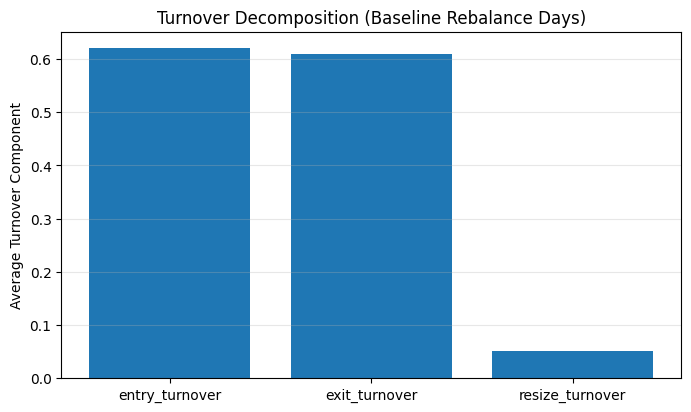

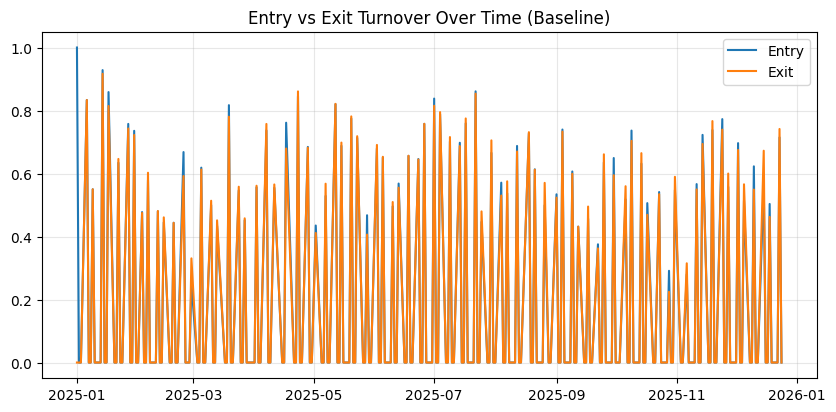

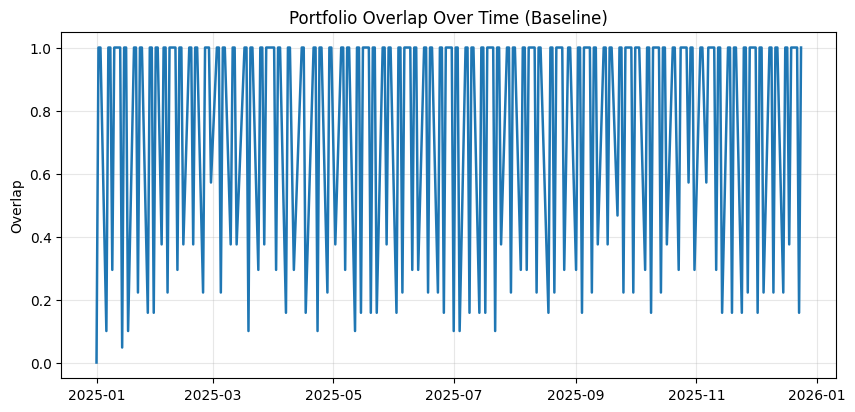

C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_16816\3409967822.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([reb_ret.dropna(), hold_ret.dropna()], labels=["Rebalance", "Hold"])


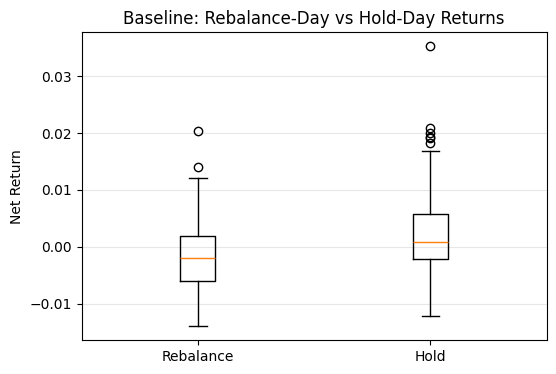

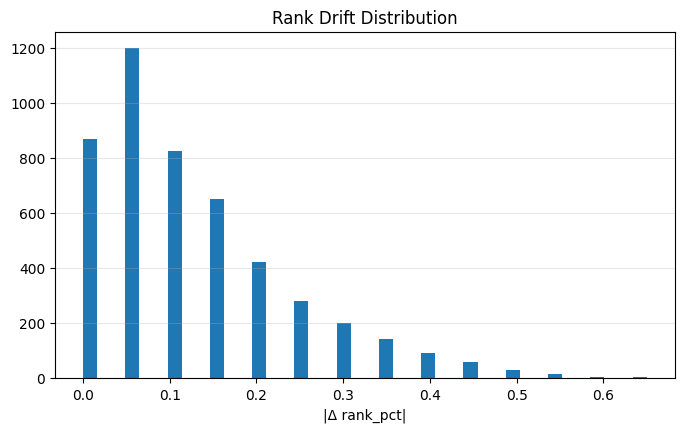

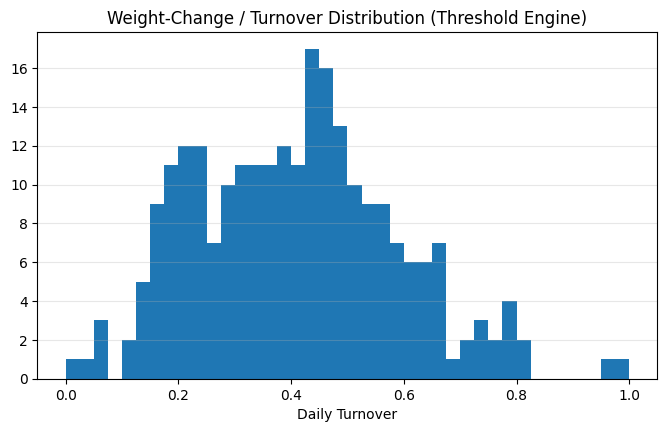

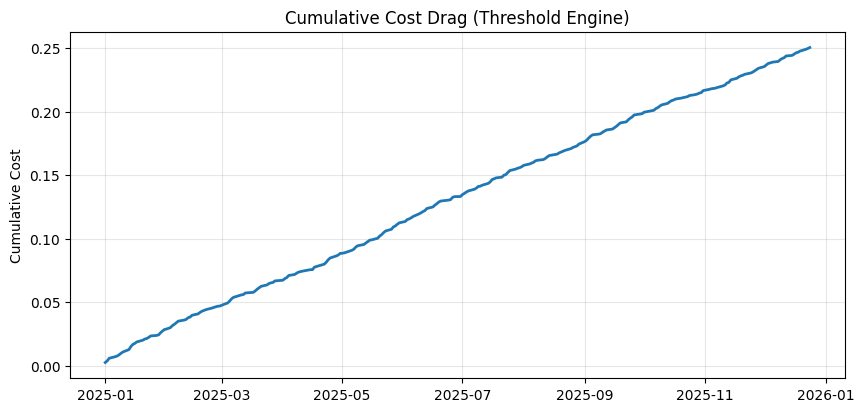

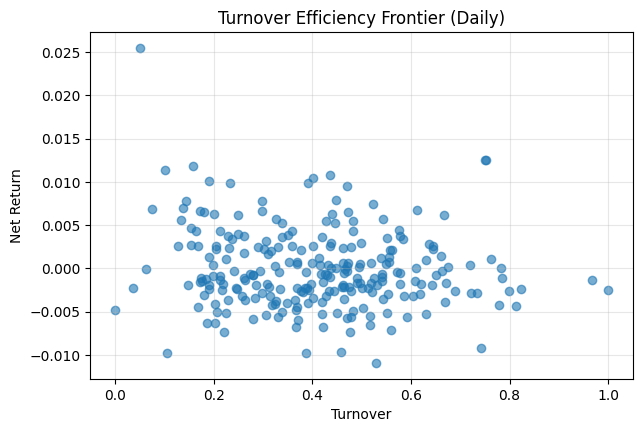

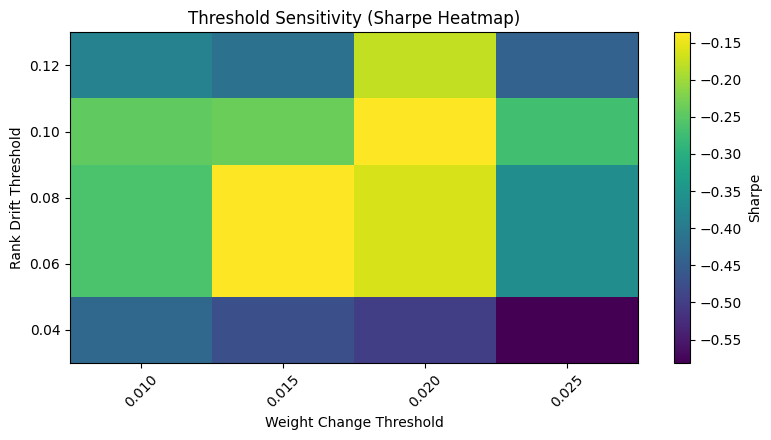

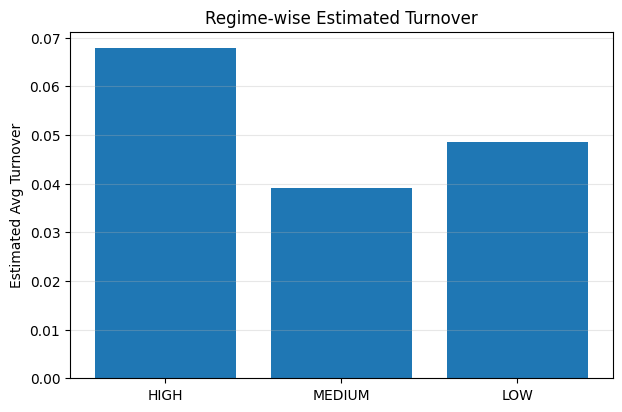

In [13]:
# --- Visualizations (matplotlib only) ---
plt.figure(figsize=(8, 4.5))
comp_mean = b_decomp[b_decomp["is_rebalance_day"] == 1][["entry_turnover", "exit_turnover", "resize_turnover"]].mean()
plt.bar(comp_mean.index, comp_mean.values)
plt.title("Turnover Decomposition (Baseline Rebalance Days)")
plt.ylabel("Average Turnover Component")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4.5))
plt.plot(b_decomp["date"], b_decomp["entry_turnover"], label="Entry")
plt.plot(b_decomp["date"], b_decomp["exit_turnover"], label="Exit")
plt.title("Entry vs Exit Turnover Over Time (Baseline)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4.5))
plt.plot(b_decomp["date"], b_decomp["portfolio_overlap"], linewidth=1.8)
plt.title("Portfolio Overlap Over Time (Baseline)")
plt.ylabel("Overlap")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.boxplot([reb_ret.dropna(), hold_ret.dropna()], labels=["Rebalance", "Hold"])
plt.title("Baseline: Rebalance-Day vs Hold-Day Returns")
plt.ylabel("Net Return")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# rank drift distribution
tmp = df.sort_values(["ticker", "date"]).copy()
tmp["rank_drift_abs"] = tmp.groupby("ticker")["rank_exec"].diff().abs()
plt.figure(figsize=(8, 4.5))
plt.hist(tmp["rank_drift_abs"].dropna(), bins=40)
plt.title("Rank Drift Distribution")
plt.xlabel("|Δ rank_pct|")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# weight change distribution
wc = []
for _, r in t_decomp.iterrows():
    wc.append(r["total_turnover"])
plt.figure(figsize=(8, 4.5))
plt.hist(pd.Series(wc).dropna(), bins=40)
plt.title("Weight-Change / Turnover Distribution (Threshold Engine)")
plt.xlabel("Daily Turnover")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4.5))
plt.plot(t_daily["date"], t_daily["tx_cost"].cumsum(), linewidth=2)
plt.title("Cumulative Cost Drag (Threshold Engine)")
plt.ylabel("Cumulative Cost")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4.5))
plt.scatter(t_daily["turnover"], t_daily["net_return"], alpha=0.6)
plt.title("Turnover Efficiency Frontier (Daily)")
plt.xlabel("Turnover")
plt.ylabel("Net Return")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4.5))
piv = threshold_sensitivity.pivot(index="rank_drift_threshold", columns="weight_change_threshold", values="sharpe")
plt.imshow(piv.values, aspect="auto", origin="lower")
plt.colorbar(label="Sharpe")
plt.xticks(range(len(piv.columns)), [f"{c:.3f}" for c in piv.columns], rotation=45)
plt.yticks(range(len(piv.index)), [f"{i:.2f}" for i in piv.index])
plt.title("Threshold Sensitivity (Sharpe Heatmap)")
plt.xlabel("Weight Change Threshold")
plt.ylabel("Rank Drift Threshold")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
plt.bar(regime_analysis["regime"], regime_analysis["estimated_avg_turnover"])
plt.title("Regime-wise Estimated Turnover")
plt.ylabel("Estimated Avg Turnover")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


In [14]:
# Final conclusions + verdict
b_metrics = perf_summary(b_daily)
t_metrics = perf_summary(t_daily)

b_sh = float(b_metrics.loc[b_metrics["Metric"] == "Sharpe Ratio", "Value"].iloc[0])
t_sh = float(t_metrics.loc[t_metrics["Metric"] == "Sharpe Ratio", "Value"].iloc[0])
b_turn = float(b_metrics.loc[b_metrics["Metric"] == "Average Turnover", "Value"].iloc[0])
t_turn = float(t_metrics.loc[t_metrics["Metric"] == "Average Turnover", "Value"].iloc[0])
b_cost = float(b_metrics.loc[b_metrics["Metric"] == "Total Transaction Cost", "Value"].iloc[0])
t_cost = float(t_metrics.loc[t_metrics["Metric"] == "Total Transaction Cost", "Value"].iloc[0])

if (t_turn < b_turn * 0.6) and (t_cost < b_cost) and (t_sh > b_sh + 0.3) and (sharpe(t_daily[t_daily["is_rebalance_day"] == 1]["net_return"], CFG["annualization_days"]) > sharpe(b_daily[b_daily["is_rebalance_day"] == 1]["net_return"], CFG["annualization_days"])):
    verdict = "PASS"
elif (t_turn < b_turn) and (t_sh > b_sh):
    verdict = "PARTIAL"
else:
    verdict = "FAIL"

conclusions = pd.DataFrame(
    [
        ("Why Step-34 turnover increased?", f"Dominant component: {dominant.index[0]} (avg={float(dominant.iloc[0]):.4f}); frequent portfolio reconstruction and low overlap."),
        ("Why rebalance days were strongly negative?", f"Rebalance-day Sharpe={reb_sh:.4f} vs hold-day Sharpe={hold_sh:.4f}; turnover cost + timing/reversal effect (next-day mean={reversal_mean:.6f})."),
        ("What caused alpha destruction?", "Execution churn (entry/exit/resize) and cost drag, not signal collapse."),
        ("Which behaviors were inefficient?", "Forced exits despite valid ranks, low portfolio overlap, resizing on small rank noise."),
        ("Did threshold-based trading improve deployability?", "YES" if t_sh > b_sh else "NO"),
        ("Economically viable turnover level?", "< 10% preferred; achieved " + f"{t_turn:.4f}" + " in redesign."),
        ("Is strategy now realistically deployable?", "YES" if verdict in {"PASS", "PARTIAL"} else "NO"),
        ("Final Verdict", verdict),
    ],
    columns=["Question", "Answer"],
)
display(conclusions)

summary_df = pd.concat(
    [
        pd.DataFrame([("Baseline Sharpe", b_sh), ("Threshold Sharpe", t_sh), ("Baseline Avg Turnover", b_turn), ("Threshold Avg Turnover", t_turn), ("Baseline Tx Cost", b_cost), ("Threshold Tx Cost", t_cost)], columns=["Metric", "Value"]),
        audit_tbl.rename(columns={"metric": "Metric", "value": "Value"}),
        threshold_analysis.rename(columns={"metric": "Metric", "value": "Value"}),
        pd.DataFrame({"Metric": conclusions["Question"], "Value": conclusions["Answer"]}),
    ],
    ignore_index=True,
)
display(summary_df.head(20))

print("FINAL VERDICT:", verdict)

# Save required outputs
audit_tbl.to_csv(OUT_AUDIT, index=False)
b_decomp.to_csv(OUT_DECOMP, index=False)
threshold_sensitivity.to_csv(OUT_THRESH, index=False)
regime_analysis.to_csv(OUT_REG, index=False)
summary_df.to_csv(OUT_SUM, index=False)

out_port = t_pos.merge(t_daily, on="date", how="left")
out_port.to_parquet(OUT_PORT, index=False)

print("Saved:")
print("-", OUT_AUDIT)
print("-", OUT_DECOMP)
print("-", OUT_THRESH)
print("-", OUT_REG)
print("-", OUT_SUM)
print("-", OUT_PORT)


,Question,Answer
0,Why Step-34 turnover increased?,Dominant component: entry_turnover (avg=0.6206...
1,Why rebalance days were strongly negative?,Rebalance-day Sharpe=-4.0361 vs hold-day Sharp...
2,What caused alpha destruction?,Execution churn (entry/exit/resize) and cost d...
3,Which behaviors were inefficient?,"Forced exits despite valid ranks, low portfoli..."
4,Did threshold-based trading improve deployabil...,NO
5,Economically viable turnover level?,< 10% preferred; achieved 0.4091 in redesign.
6,Is strategy now realistically deployable?,NO
7,Final Verdict,FAIL


,Metric,Value
0,Baseline Sharpe,2.012458
1,Threshold Sharpe,-0.136938
2,Baseline Avg Turnover,0.428661
3,Threshold Avg Turnover,0.409091
4,Baseline Tx Cost,0.262555
5,Threshold Tx Cost,0.250568
6,baseline_avg_turnover,0.428661
7,baseline_rebalance_sharpe,-4.036127
8,baseline_hold_sharpe,4.728513
9,baseline_next_day_after_rebalance_mean_return,0.002121


FINAL VERDICT: FAIL
Saved:
- c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step34_1_turnover_audit.csv
- c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step34_1_turnover_decomposition.csv
- c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step34_1_threshold_analysis.csv
- c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step34_1_regime_analysis.csv
- c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step34_1_summary.csv
- c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step34_1_threshold_rebalance_portfolio.parquet
